In [ ]:
# This notebook demonstrates how to use recalibration of MSI data using the DeltaMSI package. 
# The notebook includes steps for loading the data, extracting calibrant m/z values from METASPACE annotations, performing recalibration, computing mean spectra, picking peaks, extracting ion images, 
# and visualizing the results. Make sure to adjust the file paths and parameters according to your specific dataset and analysis needs.

In [1]:
import deltamsi
from deltamsi.core.msicube import MSICube
import matplotlib.pyplot as plt

In [ ]:
# replace "/directory/containing/imzml/data" with the actual path to the directory containing your imzML data. The directory should contain the imzML file and the corresponding .ibd file for the dataset you want to analyze. Make sure to adjust the path according to your file system and dataset organization.
# imzml files can be downloaded from the METASPACE platform (https://metaspace2020.eu/) ID ds=2019-11-05_23h15m11s. Once you have the imzML files, you can use the code below to load the data into an MSICube object and perform the analysis as described in the notebook.
cube = MSICube(data_directory="/directory/containing/imzml/data")

INFO: MSICube initialized with 1 samples found.


In [ ]:
# compute mean spectra for each sample and globally, then pick peaks on the global mean spectrum.
cube.compute_mean_spectra(scope = "samples" ,mode="centroid",mass_accuracy_ppm=None, tolerance_da =0.0005 , min_mz=100.0, max_mz=1200, binning_p=0.0001 )
cube.compute_mean_spectra(scope = "global",tic_normalize=False)
cube.pick_peaks(topn=3000,binning_p=0.0001,distance_ppm=5)

INFO: Calculating mean spectrum for: zebra_old_cent_pp (Mode: centroid)
INFO: Mean spectra calculated and stored.
INFO: Computing global mean spectrum...
INFO: Global mean spectrum calculated and stored in adata.uns['mean_spectrum_global'].
INFO: Starting peak picking on the global mean spectrum.
INFO: Peak picking finished. 3000 mz selected.
INFO: Selected mz values stored in adata.var and adata.uns['peak_picking_options'].


In [ ]:
# extract the ion images for the picked peaks, using a tolerance of 1 ppm for matching the m/z values in the spectra to the picked peaks. This step will create a new variable in the adata.var DataFrame with the key "mz_XXX" for each picked peak, where XXX is the m/z value of the peak. The ion images will be stored as arrays in this variable, and can be accessed and visualized using the appropriate functions in the MSICube class.
cube.extract_matrix(tol_ppm=1)

INFO: Starting extraction of peak intensity matrix (X) for all samples.
INFO: Extracting matrix for sample: zebra_old_cent_pp
INFO: Concatenating data from all samples...
INFO: Extraction complete. Final shape: (11050, 3000) (Pixels x Peaks). Data stored in adata.X, adata.obsm['spatial'], adata.obs['sample'].


In [ ]:
# save the MSICube object to a file for later use. This will allow you to reload the object and access the computed mean spectra, picked peaks, and extracted ion images without having to repeat the computationally intensive steps of loading the data and processing it. You can specify the file path and name for saving the MSICube object, and it will be saved in a format that can be easily reloaded using the appropriate function in the MSICube class.
cube.save()

INFO: AnnData saved to /home/rlarocca20/msi_data/zebrafish/adata.h5ad (format=h5ad).


'/home/rlarocca20/msi_data/zebrafish/adata.h5ad'

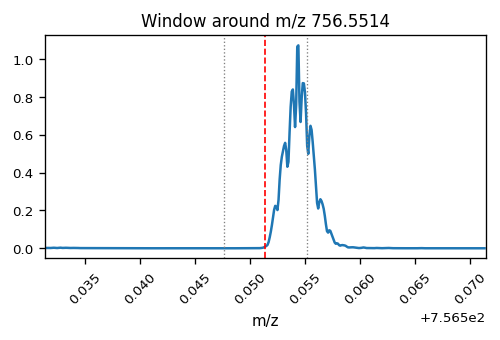

In [ ]:
# visualize the ion peaks for m/z 756.5514 with a tolerance of 5 ppm and a span of 0.04 Da. 
cube.plot_peak_windows(peak_mzs=[756.5514],tol_ppm=5,span_da=0.04)

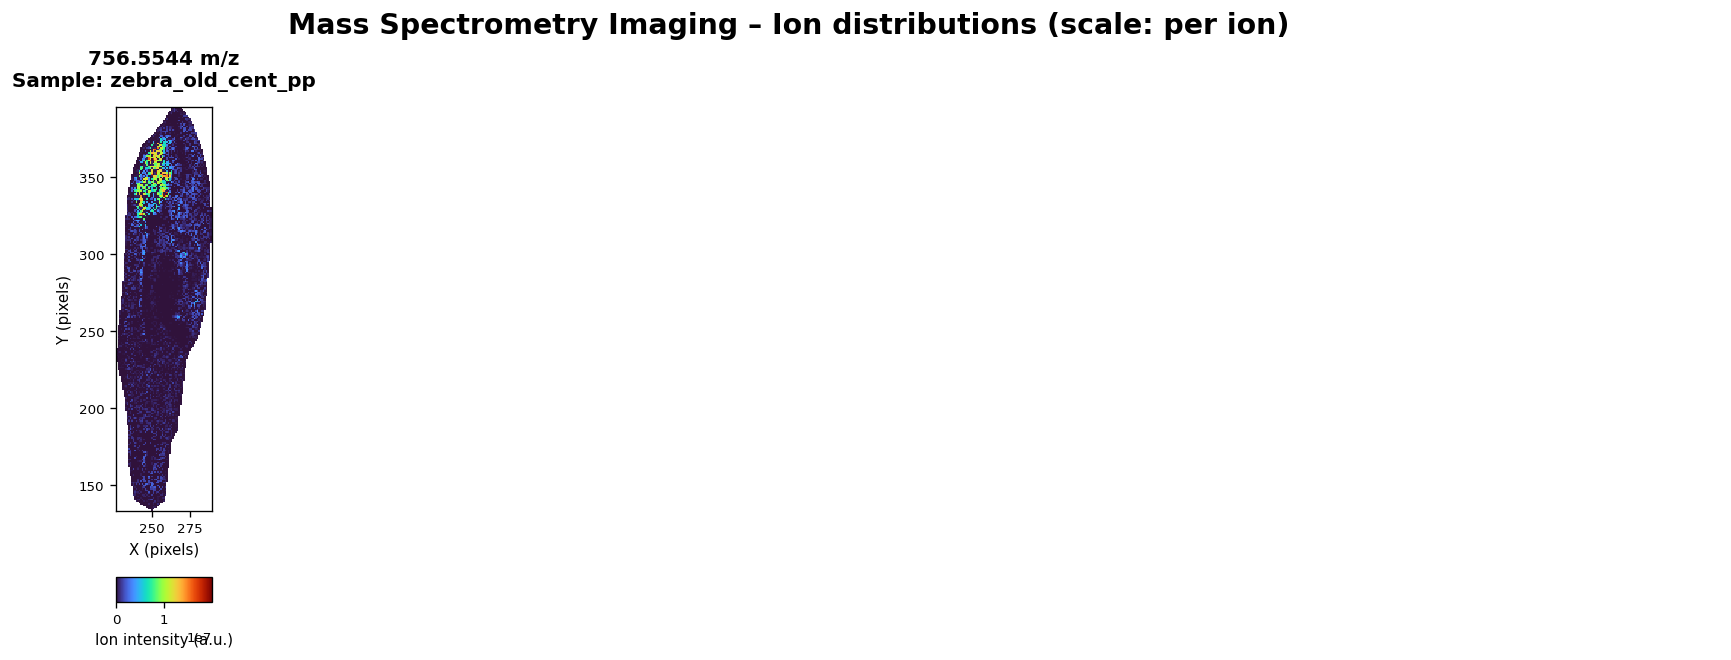

In [ ]:
# visualize the ion image for m/z 756.5514 
cube.plot_ion_images(mz=[756.5514], scale_mode="per_ion",layer = "RAW")

In [ ]:
import deltamsi
from deltamsi.core.msicube import MSICube
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

cube = MSICube("/directory/containing/imzml/data")
cube.load()

INFO: MSICube initialized with 1 samples found.
INFO: AnnData loaded from /home/rlarocca20/msi_data/zebrafish/adata.h5ad (format=h5ad).


AnnData object with n_obs × n_vars = 11050 × 3000
    obs: 'sample'
    var: 'mz'
    uns: 'matrix_extraction_options', 'mean_spectra', 'mean_spectra_options', 'mean_spectra_samples', 'mean_spectrum_global', 'mean_spectrum_global_options', 'peak_picking_options'
    obsm: 'spatial'
    layers: 'RAW'

In [ ]:
# Process metaspace annotations to extract the m/z values of the calibrants. 
# The annotations are stored in a CSV file that can be downloaded from the METASPACE platform (https://metaspace2020.eu/) for the dataset you are analyzing. 
# The code below reads the CSV file, filters the annotations based on specific criteria (Polarity = "Positive", Database = "LipidMaps - 2017-12-12", FDR = 10%, Matrix = "HCCA"), and extracts the unique m/z values of the calibrants. Finally, it saves the m/z values to a new CSV file that can be used for recalibration of the MSI data.
metaspacedb = pd.read_csv("./data/metaspace_annotations_zebrafish.csv",skiprows=2)
calibrant_mz = np.unique(metaspacedb["mz"])
np.savetxt("./data/calibrants.csv", calibrant_mz, delimiter=",")

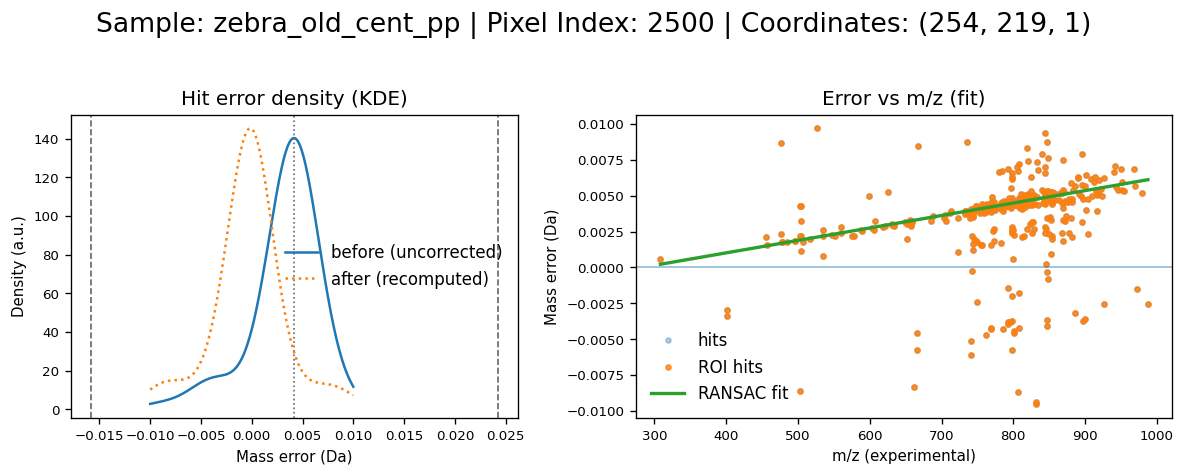

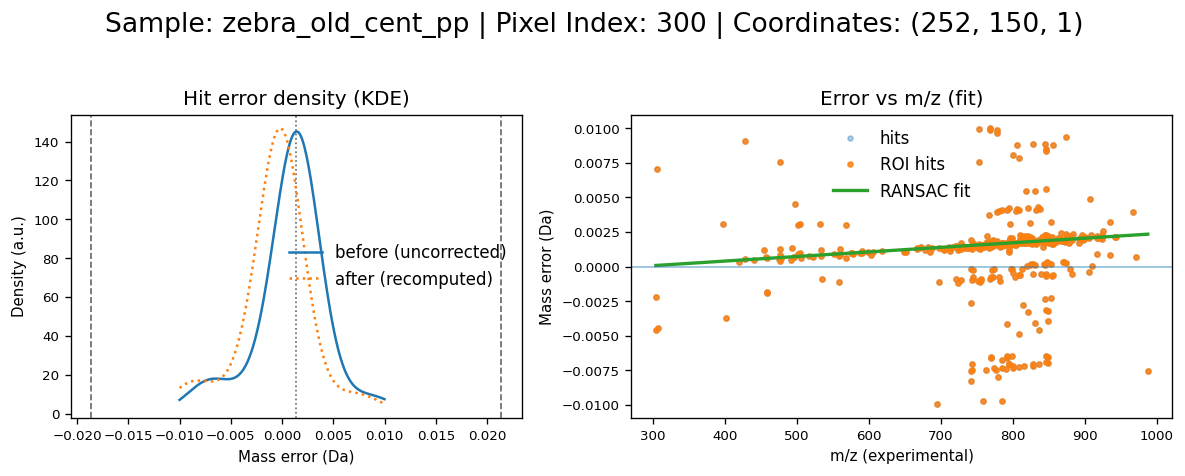

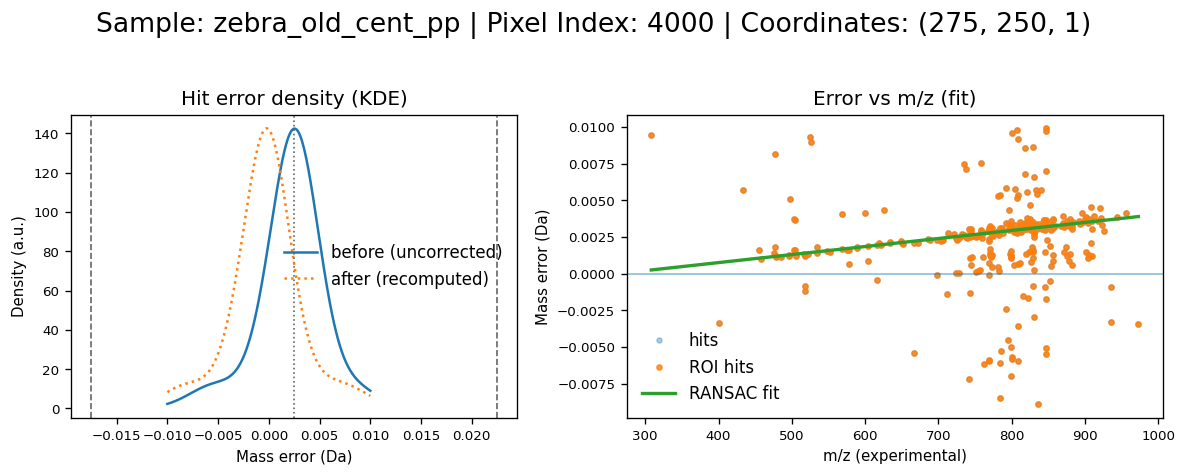

In [ ]:
# Test and visualize the recalibration results using the calibrant m/z values extracted from the METASPACE annotations. 
# The code below uses the plot_recalibration function to visualize the recalibration results for a specific sample (sample_name='zebra_old_cent_pp')
#  and a specific pixel index (pixel_idx=[2500,300,4000]). 
# The function will use the calibrant m/z values from the specified database mass file ("./data/calibrants.csv") 
# and the specified options for recalibration (tol_da=0.01, n_peaks=1000, roi_halfwidth_da=0.02, kde_bw_da=0.002) to perform the recalibration and visualize the results.
from deltamsi.params.options import RecalibrationOptions
options = RecalibrationOptions(tol_da=0.01, n_peaks=1000,roi_halfwidth_da=0.02,kde_bw_da=0.002)
cube.plot_recalibration(sample_name='zebra_old_cent_pp',database_mass_file="./data//calibrants.csv",options=options,pixel_idx=[2500,300,4000])



In [ ]:
# perform the recalibration of the MSI data using the calibrant m/z values extracted from the METASPACE annotations.
cube.recalibrate( database_mass_file="./data/calibrants.csv",options=options,n_workers=1)

INFO: Starting recalibration for 1 samples...
INFO: Output files will be saved in: /home/rlarocca20/msi_data/zebrafish/recalibrated_data


/home/rlarocca20/anaconda3/envs/pymsix-acc-dev/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/rlarocca20/anaconda3/envs/pymsix-acc-dev/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/rlarocca20/anaconda3/envs/pymsix-acc-dev/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/rlarocca20/anaconda3/envs/pymsix-acc-dev/lib/python3.11/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/home/rlarocca20/anaconda3/envs/pymsix-a

INFO: Recalibration successful for zebra_old_cent_pp.
INFO: Recalibration successful for 1 samples.
INFO: MSICube sample paths updated to use the recalibrated files.


In [ ]:
cube_recal = MSICube(data_directory="/directory/containing/imzml/data/recalibrated_data")

INFO: MSICube initialized with 1 samples found.


In [ ]:
# compute mean spectra for each sample and globally, then pick peaks on the global mean spectrum of the recalibrated data.
cube_recal.compute_mean_spectra(scope = "samples" ,mode="centroid",mass_accuracy_ppm=None, tolerance_da =0.0005 , min_mz=100.0, max_mz=1200, binning_p=0.0001 )
cube_recal.compute_mean_spectra(scope = "global",tic_normalize=False)
cube_recal.pick_peaks(topn=3000,binning_p=0.0001,distance_ppm=5)

INFO: Calculating mean spectrum for: zebra_old_cent_pp (Mode: centroid)
INFO: Mean spectra calculated and stored.
INFO: Computing global mean spectrum...
INFO: Global mean spectrum calculated and stored in adata.uns['mean_spectrum_global'].
INFO: Starting peak picking on the global mean spectrum.
INFO: Peak picking finished. 3000 mz selected.
INFO: Selected mz values stored in adata.var and adata.uns['peak_picking_options'].


In [ ]:
# extract the ion images for the picked peaks, using a tolerance of 1 ppm for matching the m/z values in the spectra to the picked peaks. This step will create a new variable in the adata.var DataFrame with the key "mz_XXX" for each picked peak, where XXX is the m/z value of the peak. The ion images will be stored as arrays in this variable, and can be accessed and visualized using the appropriate functions in the MSICube class.
cube_recal.extract_matrix(tol_ppm=1)

INFO: Starting extraction of peak intensity matrix (X) for all samples.
INFO: Extracting matrix for sample: zebra_old_cent_pp
INFO: Concatenating data from all samples...
INFO: Extraction complete. Final shape: (11050, 3000) (Pixels x Peaks). Data stored in adata.X, adata.obsm['spatial'], adata.obs['sample'].


In [ ]:
# save the MSICube object to a file for later use. This will allow you to reload the object and access the computed mean spectra, picked peaks, and extracted ion images without having to repeat the computationally intensive steps of loading the data and processing it. You can specify the file path and name for saving the MSICube object, and it will be saved in a format that can be easily reloaded using the appropriate function in the MSICube class.
cube_recal.save()

INFO: AnnData saved to /home/rlarocca20/msi_data/zebrafish/recalibrated_data/adata.h5ad (format=h5ad).


'/home/rlarocca20/msi_data/zebrafish/recalibrated_data/adata.h5ad'

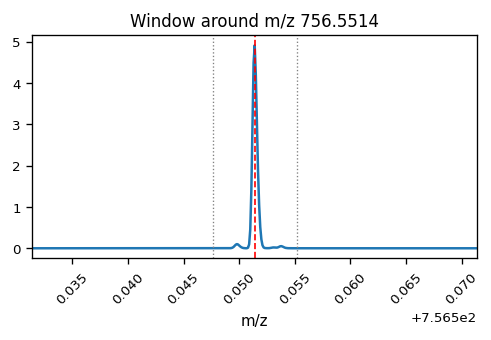

In [ ]:
# visualize the ion peaks for m/z 756.5514 with a tolerance of 5 ppm and a span of 0.04 Da from the recalibrated data.
cube_recal.plot_peak_windows(peak_mzs=[756.5514],tol_ppm=5,span_da=0.04)

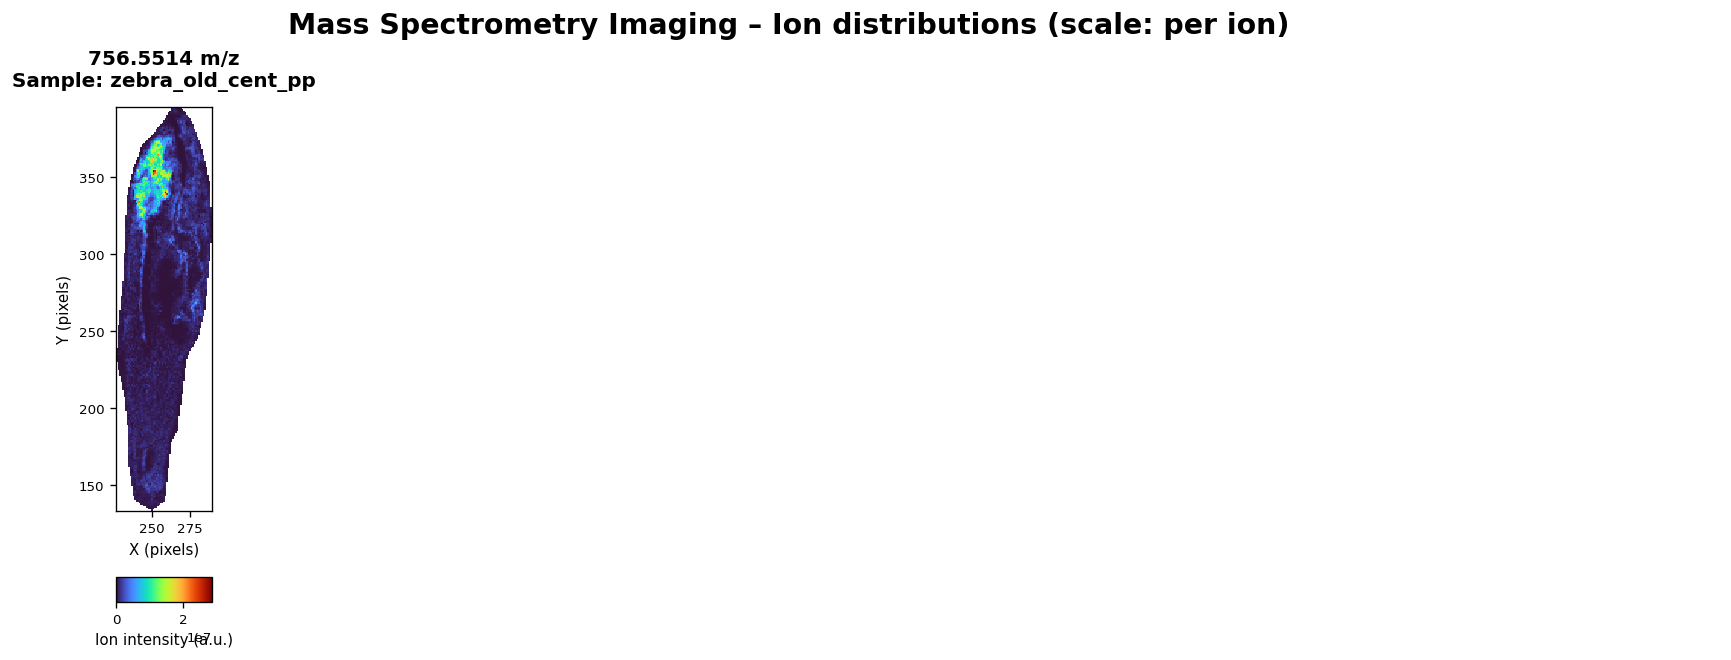

In [32]:
cube_recal.plot_ion_images(mz=[756.5514], scale_mode="per_ion",layer = "RAW")